Use this notebook to extract GTFS Data from 511 to get realtime vehicle locations and speeds.

In [10]:
import pandas as pd
import geopandas as gpd
import requests
from google.transit import gtfs_realtime_pb2
from tqdm import tqdm
import time
from datetime import datetime
from shapely.geometry import Point

In [ ]:
# 511 API
api_key = ''
url = f'https://api.511.org/Transit/VehiclePositions?api_key={api_key}&agency=SC'

columns = ['bus_id', 'trip_id', 'route_id', 'lat', 'lon', 'time', 'speed', 'direction']
selected_routes = ['22', 'Rapid 522', '23', 'Rapid 523', '25', '60']

def fetch_realtime_positions_speeds(api_url, iterations=1, delay=60, existing_bus_data=pd.DataFrame(columns=columns)):
    '''
    This function takes in a 511 API URL, a given number of iterations, and a given delay, in seconds.
    Then, every cycle, it will query 511 for the bus locations, speed, travel direction, etc.
    '''

    count = 0
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_path = f"../02-data/cleaned_data/vehicle_route_location_speed_data_{timestamp}.csv"

    try:
        with tqdm(total=iterations) as progress_bar:
            while count < iterations:
                response = requests.get(api_url)

                if response.status_code == 200:
                    
                    try:
                        #Get GTFS response
                        feed = gtfs_realtime_pb2.FeedMessage()
                        feed.ParseFromString(response.content)

                        data_list = []

                        #For each vehicle
                        for entity in feed.entity:
                            if entity.HasField('vehicle'):
                                vehicle = entity.vehicle
                                trip = vehicle.trip
                                route_id = trip.route_id

                                #Check if the route_id is in the list of desired route IDs
                                if route_id in selected_routes:

                                    #Extract the vehicle's details
                                    vehicle_data = {
                                        'bus_id': entity.id,
                                        'trip_id': trip.trip_id,
                                        'route_id': route_id,
                                        'lat': vehicle.position.latitude,
                                        'lon': vehicle.position.longitude,
                                        'time': vehicle.timestamp,
                                        'speed': vehicle.position.speed,
                                        'direction' : trip.direction_id
                                    }

                                    data_list.append(vehicle_data)
                        
                        new_bus_data = pd.DataFrame(data_list, columns=existing_bus_data.columns)
                        existing_bus_data = pd.concat([existing_bus_data, new_bus_data], ignore_index=True)

                    except Exception as e:
                        print(e)
                    
                else:
                    print(f"Error: {response.status_code} - {response.text}")
                
                if count < iterations - 1:  # No delay after the last iteration
                    time.sleep(delay)
                
                count += 1
                progress_bar.update(1)
    
        existing_bus_data.to_csv(file_path, index=False)

    except:
        existing_bus_data.to_csv(file_path, index=False)

    return existing_bus_data

In [ ]:
#THIS CANT BE INTERRUPTED EASILY ONCE STARTED
#BEWARE
bus_data = fetch_realtime_positions_speeds(url, iterations=120, delay = 30)
bus_data.drop_duplicates()

  0%|          | 0/120 [00:00<?, ?it/s]C:\Users\thele\AppData\Local\Temp\ipykernel_28680\2290904101.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  existing_bus_data = pd.concat([existing_bus_data, new_bus_data], ignore_index=True)


In [ ]:
bus_gdf_geometry = [Point(xy) for xy in zip(bus_data["lon"], bus_data["lat"])]

In [ ]:
bus_gdf = gpd.GeoDataFrame(bus_data, geometry=bus_gdf_geometry, crs="EPSG:4326")
bus_gdf = bus_gdf.to_crs("EPSG:2227")
bus_gdf

,bus_id,trip_id,route_id,lat,lon,time,speed,direction,geometry
0,0130,3926108,60,37.410076,-121.891586,1774480251,0.000514,1,POINT (6157508.041 1974788.768)
1,0131,3926044,60,37.279446,-121.948853,1774480251,0.001029,0,POINT (6140141.297 1927483.923)
2,0132,3926043,60,37.301311,-121.949852,1774480251,0.001543,0,POINT (6139973.862 1935448.865)
3,0133,3926039,60,37.387226,-121.886299,1774480251,0.000514,0,POINT (6158920.264 1966447.103)
4,0134,3926102,60,37.279678,-121.949791,1774480251,0.001543,1,POINT (6139869.611 1927572.866)
...,...,...,...,...,...,...,...,...,...
7356,8328,3916828,22,37.344299,-121.873589,1774483842,11.916488,1,POINT (6162383.304 1950764.551)
7357,8329,3916740,22,37.369461,-122.038979,1774483842,8.441960,0,POINT (6114461.41 1960672.808)
7358,8335,3916829,22,37.327473,-121.811317,1774483842,0.001029,1,POINT (6180397.623 1944378.873)
7359,8336,3916767,22,37.344265,-121.847435,1774483842,0.002572,0,POINT (6169985.074 1950641.533)


<Axes: >

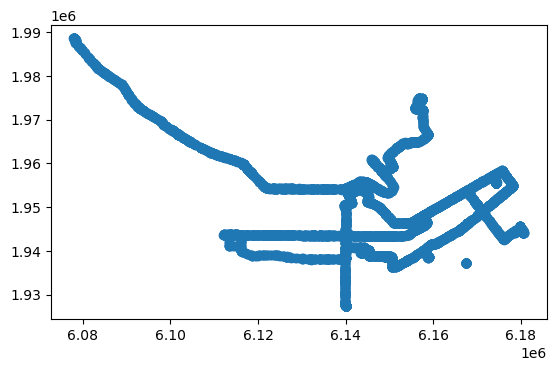

In [ ]:
bus_gdf.plot()